Sakshi Jha 00211192024 AIML Group- H Subject: Recent trends in AI

**Aim:** To compare the performance of RoBERTa, DistilBERT, BERT, and LSTM models for text classification using a common text dataset.

**Objectives:**
To understand transformer-based models such as BERT, DistilBERT, and RoBERTa.
To understand the working of LSTM for text classification.
To preprocess and prepare text data for classification.
To train and evaluate BERT, DistilBERT, RoBERTa, and LSTM models.
To compare the performance of the four models using suitable evaluation metrics.

**Requirements:**
PyTorch
Hugging Face Transformers
Hugging Face Datasets
Scikit-learn
Pandas
NumPy
Matplotlib


**Theory:**
BERT (Bidirectional Encoder Representations from Transformers)
A transformer-based language model that learns contextual representations by considering both the left and right context of words.

DistilBERT
A smaller and faster version of BERT created using knowledge distillation while retaining much of BERT's performance.

RoBERTa (Robustly Optimized BERT Pretraining Approach)
An optimized version of BERT that uses improved pretraining strategies and training procedures.

LSTM (Long Short-Term Memory)
A type of recurrent neural network designed to handle sequential data and learn long-term dependencies in text.

**DATASET:** IMDB Movie Reviews dataset

In [1]:
import numpy as np #import libraries
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Libraries imported successfully!
PyTorch version: 2.11.0+cu128
GPU available: True


In [2]:
# Load the IMDB Dataset
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

print("Dataset loaded successfully!")
print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [3]:
# Create a Manageable Dataset 2,000 training reviews 500 testing reviews
# Same samples for all four models

train_data = dataset["train"].shuffle(seed=42).select(range(2000))
test_data = dataset["test"].shuffle(seed=42).select(range(500))

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

print("\nFirst training review:")
print(train_data[0]["text"])

print("\nFirst training label:")
print(train_data[0]["label"])

Training samples: 2000
Testing samples: 500

First training review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it's the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...

First training label:
1



1 → Positive: That makes sense because the review contains positive comments about the actors/acting.

In [4]:
# Check Class Distribution
from collections import Counter

train_labels = train_data["label"]
test_labels = test_data["label"]

print("Training label distribution:")
print(Counter(train_labels))

print("\nTesting label distribution:")
print(Counter(test_labels))

print("\nLabel meaning:")
print("0 = Negative")
print("1 = Positive")

Training label distribution:
Counter({1: 1000, 0: 1000})

Testing label distribution:
Counter({0: 254, 1: 246})

Label meaning:
0 = Negative
1 = Positive


It is a balanced dataset

In [5]:
# Convert Dataset to Pandas
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("Training DataFrame shape:", train_df.shape)
print("Testing DataFrame shape:", test_df.shape)

print("\nTraining DataFrame:")
print(train_df.head())

Training DataFrame shape: (2000, 2)
Testing DataFrame shape: (500, 2)

Training DataFrame:
                                                text  label
0  There is no relation at all between Fortier an...      1
1  This movie is a great. The plot is very true t...      1
2  George P. Cosmatos' "Rambo: First Blood Part I...      0
3  In the process of trying to establish the audi...      1
4  Yeh, I know -- you're quivering with excitemen...      0


It will convert the selected Hugging Face datasets into DataFrames. This will make preprocessing easier and can use the same text/labels for all four models.

text tokenization. Since BERT, DistilBERT, and RoBERTa each use their own tokenizer, first prepare them separately. LSTM will use a standard Keras tokenizer.

In [6]:
# Cell 6 — Install Required Libraries
!pip install -q transformers datasets

In [8]:
# Checking GPU and Transformer Library
import transformers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Transformers version:", transformers.__version__)
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Transformers version: 5.16.1
Selected device: cuda
GPU: Tesla T4


In [9]:
# Load the Three Tokenizers

from transformers import AutoTokenizer

# Load tokenizers for the three Transformer models
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
distilbert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

print("BERT tokenizer loaded successfully!")
print("DistilBERT tokenizer loaded successfully!")
print("RoBERTa tokenizer loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

BERT tokenizer loaded successfully!
DistilBERT tokenizer loaded successfully!
RoBERTa tokenizer loaded successfully!


BERT tokenizer → converts text into BERT-compatible tokens.
DistilBERT tokenizer → converts text into DistilBERT-compatible tokens.
RoBERTa tokenizer → converts text into RoBERTa-compatible tokens. I will take maximum sequence length later so that all reviews have a consistent input size.

In [10]:
# Tokenize the Dataset
# Extract text and labels
train_texts = train_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_df["label"].tolist()
test_labels = test_df["label"].tolist()

# Maximum sequence length
max_length = 128

# Tokenize training data
bert_train = bert_tokenizer(
    train_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

distilbert_train = distilbert_tokenizer(
    train_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

roberta_train = roberta_tokenizer(
    train_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

# Tokenize testing data
bert_test = bert_tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

distilbert_test = distilbert_tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

roberta_test = roberta_tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

print("Tokenization completed successfully!")
print("Maximum sequence length:", max_length)
print("BERT input shape:", bert_train["input_ids"].shape)
print("DistilBERT input shape:", distilbert_train["input_ids"].shape)
print("RoBERTa input shape:", roberta_train["input_ids"].shape)

Tokenization completed successfully!
Maximum sequence length: 128
BERT input shape: torch.Size([2000, 128])
DistilBERT input shape: torch.Size([2000, 128])
RoBERTa input shape: torch.Size([2000, 128])


convert the reviews into numerical tokens for the three Transformer models.

**WHY 128:** Reviews can have different lengths. I make every input exactly 128 tokens:
Short reviews → padded
Long reviews → truncated

In [11]:
# Create PyTorch Datasets and DataLoaders
from torch.utils.data import TensorDataset, DataLoader

# Convert labels to PyTorch tensors
train_labels_tensor = torch.tensor(train_labels)
test_labels_tensor = torch.tensor(test_labels)

# Create datasets
bert_train_dataset = TensorDataset(
    bert_train["input_ids"],
    bert_train["attention_mask"],
    train_labels_tensor
)

bert_test_dataset = TensorDataset(
    bert_test["input_ids"],
    bert_test["attention_mask"],
    test_labels_tensor
)

distilbert_train_dataset = TensorDataset(
    distilbert_train["input_ids"],
    distilbert_train["attention_mask"],
    train_labels_tensor
)

distilbert_test_dataset = TensorDataset(
    distilbert_test["input_ids"],
    distilbert_test["attention_mask"],
    test_labels_tensor
)

roberta_train_dataset = TensorDataset(
    roberta_train["input_ids"],
    roberta_train["attention_mask"],
    train_labels_tensor
)

roberta_test_dataset = TensorDataset(
    roberta_test["input_ids"],
    roberta_test["attention_mask"],
    test_labels_tensor
)

# Create DataLoaders
batch_size = 16

bert_train_loader = DataLoader(
    bert_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

bert_test_loader = DataLoader(
    bert_test_dataset,
    batch_size=batch_size
)

distilbert_train_loader = DataLoader(
    distilbert_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

distilbert_test_loader = DataLoader(
    distilbert_test_dataset,
    batch_size=batch_size
)

roberta_train_loader = DataLoader(
    roberta_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

roberta_test_loader = DataLoader(
    roberta_test_dataset,
    batch_size=batch_size
)

print("PyTorch datasets and DataLoaders created successfully!")
print("Batch size:", batch_size)
print("Number of BERT training batches:", len(bert_train_loader))
print("Number of BERT testing batches:", len(bert_test_loader))

PyTorch datasets and DataLoaders created successfully!
Batch size: 16
Number of BERT training batches: 125
Number of BERT testing batches: 32


prepare the tokenized data so it can be fed into the models in small batches during training.ame batch size will be used for the three Transformer models, keeping the comparison consistent.

## **BERT**

In [12]:
# Cell 11 — Load BERT
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

bert_model = bert_model.to(device)

print("BERT model loaded successfully!")
print("Number of labels:", bert_model.config.num_labels)
print("Device:", device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!
Number of labels: 2
Device: cuda


UNEXPECTED : The pretrained BERT checkpoint contains parameters used for its original pretraining tasks,cls.predictions and cls.seq_relationship These aren't needed for our sentiment-classification task, so Transformers reports them as UNEXPECTED.

In [14]:
# BERT Training
from torch.optim import AdamW

# Define optimizer
bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5
)

criterion = nn.CrossEntropyLoss()

epochs = 2

print("BERT training setup completed!")
print("Learning rate:", 2e-5)
print("Epochs:", epochs)
print("Loss function: Cross Entropy Loss")

BERT training setup completed!
Learning rate: 2e-05
Epochs: 2
Loss function: Cross Entropy Loss


In [15]:
# Train BERT
bert_model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in bert_train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        bert_optimizer.zero_grad()

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        loss.backward()
        bert_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(bert_train_loader)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Training Loss: {average_loss:.4f}"
    )

Epoch 1/2 - Training Loss: 0.5107
Epoch 2/2 - Training Loss: 0.2644


The loss decreased from 0.5107 → 0.2644, which indicates that BERT is learning from the IMDB sentiment data during fine-tuning.

In [16]:
# Evaluate BERT
bert_model.eval()

bert_predictions = []
bert_actual = []

with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        bert_predictions.extend(predictions.cpu().numpy())
        bert_actual.extend(labels.cpu().numpy())

bert_accuracy = accuracy_score(
    bert_actual,
    bert_predictions
)

print("BERT Test Accuracy:", bert_accuracy)
print("BERT Test Accuracy (%):", bert_accuracy * 100)

BERT Test Accuracy: 0.828
BERT Test Accuracy (%): 82.8


BERT achieved a test accuracy of 82.8% on the 500 IMDB test reviews after fine-tuning for 2 epochs.

## **DistilBERT**

In [17]:
# Load DistilBERT
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

distilbert_model = distilbert_model.to(device)

print("DistilBERT model loaded successfully!")
print("Number of labels:", distilbert_model.config.num_labels)
print("Device:", device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully!
Number of labels: 2
Device: cuda


In [18]:
# DistilBERT Training Setup
distilbert_optimizer = AdamW(
    distilbert_model.parameters(),
    lr=2e-5
)

distilbert_epochs = 2

print("DistilBERT training setup completed!")
print("Learning rate:", 2e-5)
print("Epochs:", distilbert_epochs)
print("Loss function: Cross Entropy Loss")

DistilBERT training setup completed!
Learning rate: 2e-05
Epochs: 2
Loss function: Cross Entropy Loss


In [19]:
# Train DistilBERT
distilbert_model.train()

for epoch in range(distilbert_epochs):
    total_loss = 0

    for batch in distilbert_train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        distilbert_optimizer.zero_grad()

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        loss.backward()
        distilbert_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(distilbert_train_loader)

    print(
        f"Epoch {epoch + 1}/{distilbert_epochs} - "
        f"Training Loss: {average_loss:.4f}"
    )

Epoch 1/2 - Training Loss: 0.4890
Epoch 2/2 - Training Loss: 0.2797


The training loss decreased from 0.4890 → 0.2797, which indicates that DistilBERT is learning from the training data.

In [20]:
# Evaluate DistilBERT
distilbert_model.eval()

distilbert_predictions = []
distilbert_actual = []

with torch.no_grad():
    for batch in distilbert_test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        distilbert_predictions.extend(
            predictions.cpu().numpy()
        )
        distilbert_actual.extend(
            labels.cpu().numpy()
        )

distilbert_accuracy = accuracy_score(
    distilbert_actual,
    distilbert_predictions
)

print("DistilBERT Test Accuracy:", distilbert_accuracy)
print(
    "DistilBERT Test Accuracy (%):",
    distilbert_accuracy * 100
)

DistilBERT Test Accuracy: 0.81
DistilBERT Test Accuracy (%): 81.0


BERT is slightly better than DistilBERT on 500-test-sample subset.

## **RoBERTa**

In [21]:
# Load RoBERTa
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

roberta_model = roberta_model.to(device)

print("RoBERTa model loaded successfully!")
print("Number of labels:", roberta_model.config.num_labels)
print("Device:", device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded successfully!
Number of labels: 2
Device: cuda


In [22]:
# RoBERTa Training Setup
roberta_optimizer = AdamW(
    roberta_model.parameters(),
    lr=2e-5
)

roberta_epochs = 2

print("RoBERTa training setup completed!")
print("Learning rate:", 2e-5)
print("Epochs:", roberta_epochs)
print("Loss function: Cross Entropy Loss")

RoBERTa training setup completed!
Learning rate: 2e-05
Epochs: 2
Loss function: Cross Entropy Loss


In [23]:
# Train RoBERTa
roberta_model.train()

for epoch in range(roberta_epochs):
    total_loss = 0

    for batch in roberta_train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        roberta_optimizer.zero_grad()

        outputs = roberta_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        loss.backward()
        roberta_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(roberta_train_loader)

    print(
        f"Epoch {epoch + 1}/{roberta_epochs} - "
        f"Training Loss: {average_loss:.4f}"
    )

Epoch 1/2 - Training Loss: 0.5318
Epoch 2/2 - Training Loss: 0.3015


In [24]:
# Evaluate RoBERTa
roberta_model.eval()

roberta_predictions = []
roberta_actual = []

with torch.no_grad():
    for batch in roberta_test_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = roberta_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        roberta_predictions.extend(
            predictions.cpu().numpy()
        )
        roberta_actual.extend(
            labels.cpu().numpy()
        )

roberta_accuracy = accuracy_score(
    roberta_actual,
    roberta_predictions
)

print("RoBERTa Test Accuracy:", roberta_accuracy)
print(
    "RoBERTa Test Accuracy (%):",
    roberta_accuracy * 100
)

RoBERTa Test Accuracy: 0.838
RoBERTa Test Accuracy (%): 83.8


So among the three Transformer models, RoBERTa is currently performing best on 500-test-sample subset.

## **LSTM**

In [25]:
# Prepare LSTM vocabulary
from collections import Counter

train_words = []

for text in train_texts:
    train_words.extend(text.lower().split())

word_counts = Counter(train_words)

max_vocab_size = 20000

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counts.most_common(max_vocab_size - 2):
    vocab[word] = len(vocab)

print("LSTM vocabulary created successfully!")
print("Vocabulary size:", len(vocab))
print("Padding token:", vocab["<PAD>"])
print("Unknown token:", vocab["<UNK>"])

LSTM vocabulary created successfully!
Vocabulary size: 20000
Padding token: 0
Unknown token: 1


In [26]:
# Convert Reviews to Sequences
def text_to_sequence(text):
    words = text.lower().split()

    sequence = []

    for word in words:
        sequence.append(vocab.get(word, vocab["<UNK>"]))

    return sequence


def pad_sequence(sequence, max_length=128):
    if len(sequence) > max_length:
        return sequence[:max_length]

    return sequence + [vocab["<PAD>"]] * (max_length - len(sequence))

lstm_train_sequences = [
    pad_sequence(text_to_sequence(text), 128)
    for text in train_texts
]

lstm_test_sequences = [
    pad_sequence(text_to_sequence(text), 128)
    for text in test_texts
]

lstm_train_inputs = torch.tensor(
    lstm_train_sequences,
    dtype=torch.long
)

lstm_test_inputs = torch.tensor(
    lstm_test_sequences,
    dtype=torch.long
)

print("LSTM sequences created successfully!")
print("Training input shape:", lstm_train_inputs.shape)
print("Testing input shape:", lstm_test_inputs.shape)
print("Maximum sequence length:", 128)

LSTM sequences created successfully!
Training input shape: torch.Size([2000, 128])
Testing input shape: torch.Size([500, 128])
Maximum sequence length: 128


convert each review into integer sequences using the vocabulary and keep the sequence length at 128, matching the Transformer setup.

In [27]:
# Create LSTM DataLoaders
from torch.utils.data import TensorDataset, DataLoader

lstm_train_labels = torch.tensor(
    train_labels,
    dtype=torch.long
)

lstm_test_labels = torch.tensor(
    test_labels,
    dtype=torch.long
)

lstm_train_dataset = TensorDataset(
    lstm_train_inputs,
    lstm_train_labels
)

lstm_test_dataset = TensorDataset(
    lstm_test_inputs,
    lstm_test_labels
)

lstm_batch_size = 32

lstm_train_loader = DataLoader(
    lstm_train_dataset,
    batch_size=lstm_batch_size,
    shuffle=True
)

lstm_test_loader = DataLoader(
    lstm_test_dataset,
    batch_size=lstm_batch_size
)

print("LSTM datasets and DataLoaders created successfully!")
print("Batch size:", lstm_batch_size)
print("Number of training batches:", len(lstm_train_loader))
print("Number of testing batches:", len(lstm_test_loader))

LSTM datasets and DataLoaders created successfully!
Batch size: 32
Number of training batches: 63
Number of testing batches: 16


In [28]:
# Build the LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_classes=2
    ):
        super(LSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(
            embedded
        )

        hidden = hidden[-1]

        hidden = self.dropout(hidden)

        return self.fc(hidden)


lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_classes=2
)

lstm_model = lstm_model.to(device)

print("LSTM model created successfully!")
print("Vocabulary size:", len(vocab))
print("Embedding dimension:", 128)
print("Hidden dimension:", 128)
print("Number of classes:", 2)
print("Device:", device)

LSTM model created successfully!
Vocabulary size: 20000
Embedding dimension: 128
Hidden dimension: 128
Number of classes: 2
Device: cuda


In [30]:
# LSTM Training
lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

lstm_criterion = nn.CrossEntropyLoss()

lstm_epochs = 2

print("LSTM training setup completed!")
print("Learning rate:", 0.001)
print("Epochs:", lstm_epochs)
print("Loss function: Cross Entropy Loss")

LSTM training setup completed!
Learning rate: 0.001
Epochs: 2
Loss function: Cross Entropy Loss


Input → Embedding → LSTM → Dropout → Fully Connected → 2 Classes

In [31]:
# Train the LSTM
lstm_model.train()

for epoch in range(lstm_epochs):
    total_loss = 0

    for batch in lstm_train_loader:
        inputs = batch[0].to(device)
        labels = batch[1].to(device)

        lstm_optimizer.zero_grad()

        outputs = lstm_model(inputs)

        loss = lstm_criterion(outputs, labels)

        loss.backward()
        lstm_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(lstm_train_loader)

    print(
        f"Epoch {epoch + 1}/{lstm_epochs} - "
        f"Training Loss: {average_loss:.4f}"
    )

Epoch 1/2 - Training Loss: 0.6943
Epoch 2/2 - Training Loss: 0.6642


The decrease is smaller than the Transformer models, but that's completely possible. The important thing is that the loss did decrease, so the LSTM is learning.

In [32]:
# Evaluate LSTM
lstm_model.eval()

lstm_predictions = []
lstm_actual = []

with torch.no_grad():
    for batch in lstm_test_loader:
        inputs = batch[0].to(device)
        labels = batch[1].to(device)

        outputs = lstm_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        lstm_predictions.extend(
            predictions.cpu().numpy()
        )
        lstm_actual.extend(
            labels.cpu().numpy()
        )

lstm_accuracy = accuracy_score(
    lstm_actual,
    lstm_predictions
)

print("LSTM Test Accuracy:", lstm_accuracy)
print(
    "LSTM Test Accuracy (%):",
    lstm_accuracy * 100
)

LSTM Test Accuracy: 0.486
LSTM Test Accuracy (%): 48.6


In [33]:
# Final Comparison
comparison = pd.DataFrame({
    "Model": [
        "BERT",
        "DistilBERT",
        "RoBERTa",
        "LSTM"
    ],
    "Test Accuracy (%)": [
        bert_accuracy * 100,
        distilbert_accuracy * 100,
        roberta_accuracy * 100,
        lstm_accuracy * 100
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("Final Model Comparison:")
print(comparison)

Final Model Comparison:
        Model  Test Accuracy (%)
0     RoBERTa               83.8
1        BERT               82.8
2  DistilBERT               81.0
3        LSTM               48.6


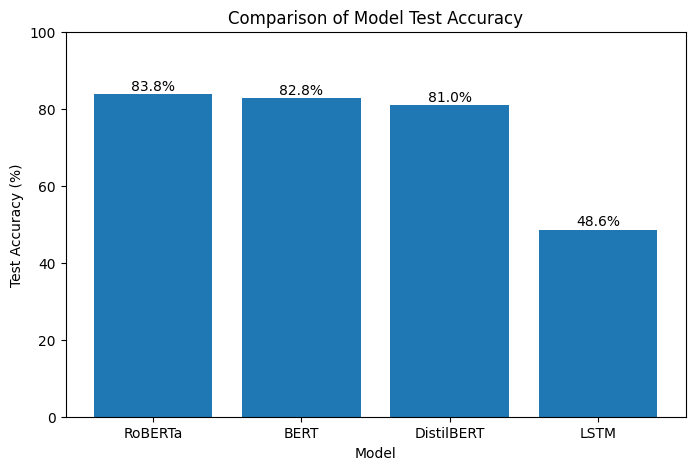

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Model Test Accuracy")

plt.ylim(0, 100)

for i, value in enumerate(comparison["Test Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [37]:
# Classification Reports
print(" --- BERT --- ")
print(classification_report(
    bert_actual,
    bert_predictions,
    target_names=["Negative", "Positive"]
))

print(" --- DistilBERT --- ")
print(classification_report(
    distilbert_actual,
    distilbert_predictions,
    target_names=["Negative", "Positive"]
))

print(" --- RoBERTa --- ")
print(classification_report(
    roberta_actual,
    roberta_predictions,
    target_names=["Negative", "Positive"]
))

print(" --- LSTM ---")
print(classification_report(
    lstm_actual,
    lstm_predictions,
    target_names=["Negative", "Positive"]
))

 --- BERT --- 
              precision    recall  f1-score   support

    Negative       0.92      0.72      0.81       254
    Positive       0.76      0.94      0.84       246

    accuracy                           0.83       500
   macro avg       0.84      0.83      0.83       500
weighted avg       0.85      0.83      0.83       500

 --- DistilBERT --- 
              precision    recall  f1-score   support

    Negative       0.77      0.89      0.83       254
    Positive       0.87      0.72      0.79       246

    accuracy                           0.81       500
   macro avg       0.82      0.81      0.81       500
weighted avg       0.82      0.81      0.81       500

 --- RoBERTa --- 
              precision    recall  f1-score   support

    Negative       0.96      0.71      0.82       254
    Positive       0.77      0.97      0.85       246

    accuracy                           0.84       500
   macro avg       0.86      0.84      0.84       500
weighted avg       0

The Transformer models have relatively strong performance on both classes, while the simple LSTM struggles particularly with the Negative class (recall 0.27).

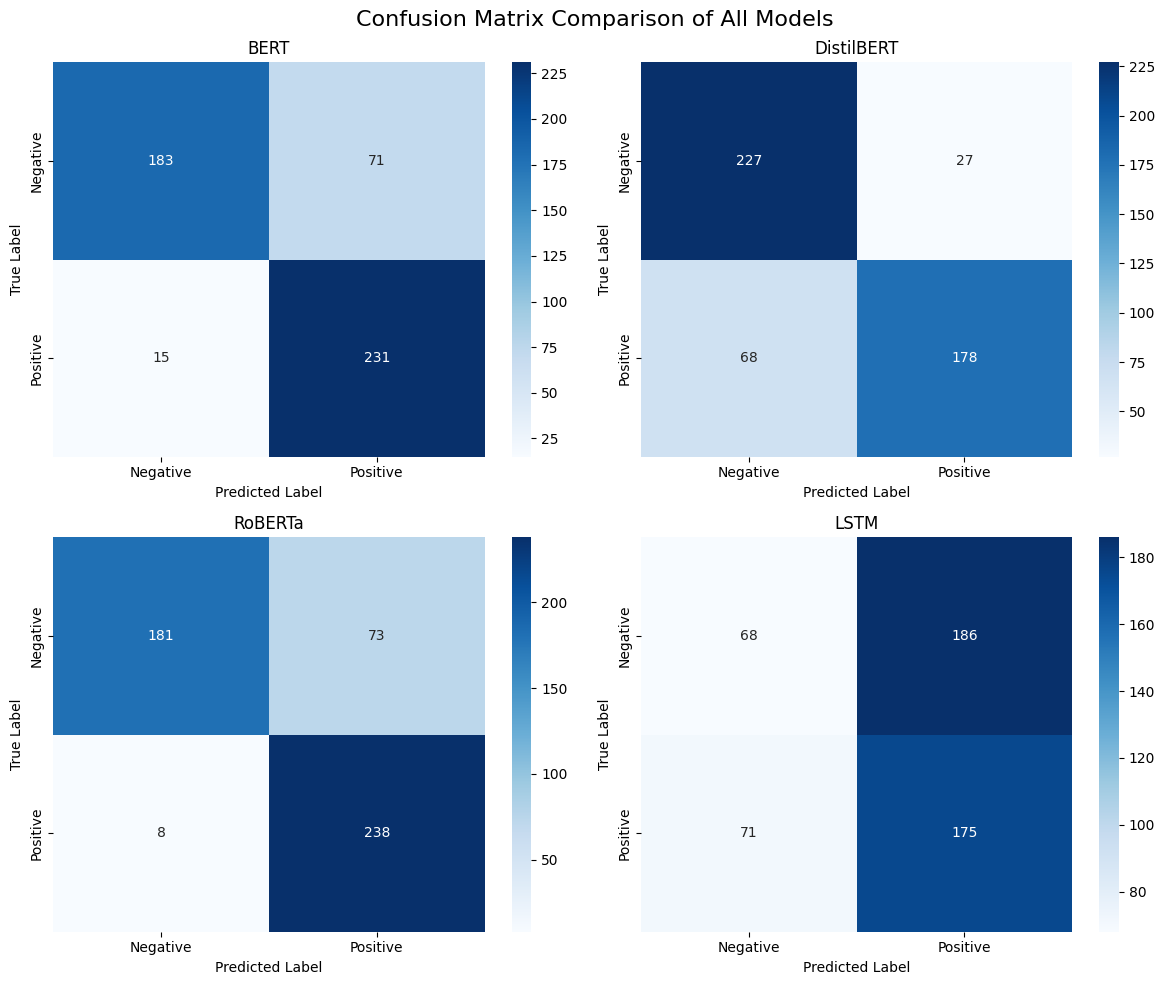

In [38]:
# Confusion Matrices for All Four Models
import seaborn as sns
import matplotlib.pyplot as plt

bert_cm = confusion_matrix(
    bert_actual,
    bert_predictions
)

distilbert_cm = confusion_matrix(
    distilbert_actual,
    distilbert_predictions
)

roberta_cm = confusion_matrix(
    roberta_actual,
    roberta_predictions
)

lstm_cm = confusion_matrix(
    lstm_actual,
    lstm_predictions
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

models_cm = [
    ("BERT", bert_cm),
    ("DistilBERT", distilbert_cm),
    ("RoBERTa", roberta_cm),
    ("LSTM", lstm_cm)
]

for ax, (model_name, cm) in zip(
    axes.flat,
    models_cm
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle(
    "Confusion Matrix Comparison of All Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

It is especially useful for showing why the LSTM's accuracy is much lower.

**Observation:**
The four models were trained and evaluated on the IMDB movie review dataset using 2000 training samples and 500 testing samples. Among the four models, RoBERTa achieved the highest test accuracy of 83.8%, followed by BERT with 82.8% and DistilBERT with 81.0%. The LSTM model achieved 48.6% accuracy. The Transformer-based models performed considerably better than the simple LSTM model for this sentiment classification task. The results show that pretrained Transformer models can capture contextual information in text more effectively than the basic LSTM architecture used in this experiment.

**Result:**
RoBERTa, BERT, DistilBERT, and LSTM were successfully implemented and compared for binary sentiment classification. RoBERTa gave the best performance with 83.8% test accuracy, while LSTM gave the lowest accuracy of 48.6%.

**Conclusion:**
The practical successfully demonstrated the comparison of RoBERTa, DistilBERT, BERT, and LSTM on a text classification task. RoBERTa performed best among the tested models, while the simple LSTM model performed poorly on the selected dataset and training configuration. Overall, the experiment demonstrates the effectiveness of pretrained Transformer-based models for modern text classification tasks.